# SmartResume: An NLP-Based Resume–Job Matching and Skill Gap Analysis System

### Mini NLP Project

**Research Question:**  
How do traditional TF-IDF similarity and modern semantic embeddings differ when matching resumes with job descriptions?

### Project Overview
SmartResume compares a resume with a job description using:
- **TF-IDF + Cosine Similarity** as a traditional lexical baseline
- **Sentence Transformers** for semantic similarity
- A **hybrid score** combining both approaches
- **Rule-based skill gap analysis** to identify matching and missing skills
- A simple **match classification** and recommendation output

> **Important:** The dataset's `ai_match_score` is treated only as an auxiliary/reference score, not as verified ground truth.


## 1. Objectives

1. Preprocess resume and job-description text.
2. Measure lexical similarity using TF-IDF and cosine similarity.
3. Measure semantic similarity using a Sentence Transformer.
4. Compare traditional and semantic similarity scores.
5. Identify matching and missing skills.
6. Combine lexical and semantic scores into a hybrid score.
7. Classify resume–job compatibility into Strong, Moderate, or Low Match.
8. Evaluate the system using genuine and deliberately mismatched resume–job pairs.
9. Demonstrate the final SmartResume analyzer on a new resume and job description.


In [33]:
# Install required packages in Google Colab
!pip install -q sentence-transformers


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import re
import ast
import random
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score

from sentence_transformers import SentenceTransformer

print("Libraries loaded successfully!")


Libraries loaded successfully!


## 2. Dataset

This project uses the **`/content/job_resume_fit.csv`** dataset from Hugging Face.

Expected Colab file path:

`/content/job_resume_fit.csv`

The dataset contains resume–job-description pairs and fields for job category, required skills, candidate skills, and several matching scores.


In [3]:
# Load dataset
DATA_PATH = "/content/job_resume_fit.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
display(df.head())


Dataset loaded successfully!
Shape: (2385, 10)


,ID,resume_text,job_text,category,job_required_skills,resume_skill_list,ai_matched_skills,ai_match_score,skill_string_match_score,fuzzy_match_score
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,Human Resources Business Partner\n------------...,HR,"['human resources management', 'talent acquisi...","['customer service', 'team management', 'marke...","['human resources management', 'employee relat...",49.40,12.50,63.24
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...",Human Resources Business Partner\n------------...,HR,"['human resources management', 'talent acquisi...","['adobe photoshop', 'adp', 'asset management',...","['human resources management', 'talent acquisi...",77.64,16.67,59.07
2,33176873,HR DIRECTOR Summary Over 2...,Human Resources Business Partner\n------------...,HR,"['human resources management', 'talent acquisi...","['recruiting', 'fmla', 'eeo', 'flsa', 'hris de...","['human resources management', 'talent acquisi...",100.00,20.83,61.89
3,27018550,HR SPECIALIST Summary Dedica...,Human Resources Business Partner\n------------...,HR,"['human resources management', 'talent acquisi...","['50 wpm typing', '10-key by touch', 'microsof...","['human resources management', 'employee relat...",32.63,8.33,52.95
4,17812897,HR MANAGER Skill Highlights ...,Human Resources Business Partner\n------------...,HR,"['human resources management', 'talent acquisi...","['hris', 'adp', 'kronos', 'lawson', 'ms office...","['human resources management', 'talent acquisi...",86.03,29.17,64.36


In [4]:
# Dataset information
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))
print("\nColumns:")
print(df.columns.tolist())

print("\nJob categories:", df["category"].nunique())
print("Categories:")
print(sorted(df["category"].dropna().unique().tolist()))


Number of rows: 2385
Number of columns: 10

Columns:
['ID', 'resume_text', 'job_text', 'category', 'job_required_skills', 'resume_skill_list', 'ai_matched_skills', 'ai_match_score', 'skill_string_match_score', 'fuzzy_match_score']

Job categories: 23
Categories:
['ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'ARTS', 'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA', 'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR', 'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER']


In [5]:
# Check missing values
missing_values = df.isnull().sum().sort_values(ascending=False)

print("Missing values by column:")
display(missing_values.to_frame("Missing Values"))


Missing values by column:


,Missing Values
ID,0
resume_text,0
job_text,0
category,0
job_required_skills,0
resume_skill_list,0
ai_matched_skills,0
ai_match_score,0
skill_string_match_score,0
fuzzy_match_score,0


## 3. Text Preprocessing

The preprocessing pipeline:
1. Converts text to lowercase.
2. Removes punctuation and special characters.
3. Normalizes repeated whitespace.
4. Returns cleaned text for similarity calculations.

This is intentionally simple and explainable for a small NLP application.


In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df["clean_resume"] = df["resume_text"].apply(clean_text)
df["clean_job"] = df["job_text"].apply(clean_text)

print("Preprocessing completed!")

print("\nOriginal resume:")
print(df.loc[0, "resume_text"][:500])

print("\nCleaned resume:")
print(df.loc[0, "clean_resume"][:500])


Preprocessing completed!

Original resume:
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-task

Cleaned resume:
hr administrator marketing associate hr administrator summary dedicated customer service manager with 15 years of experience in hospitality and customer service management respected builder and leader of customer focused teams strives to instill a shared enthusiastic commitment to customer service highlights focused on customer satisfaction team management marketing savvy conflict resolution techniques training and development skilled 

## 4. Traditional NLP Baseline — TF-IDF

**TF-IDF (Term Frequency–Inverse Document Frequency)** represents text numerically based on the importance of words.

Cosine similarity is then used to measure the angle-based similarity between the resume and job-description vectors.

A higher score indicates greater lexical overlap.


In [7]:
# Fit TF-IDF on all resumes and job descriptions together
tfidf_vectorizer = TfidfVectorizer(stop_words="english")

tfidf_matrix = tfidf_vectorizer.fit_transform(
    pd.concat([df["clean_resume"], df["clean_job"]], ignore_index=True)
)

resume_vectors = tfidf_matrix[:len(df)]
job_vectors = tfidf_matrix[len(df):]

tfidf_scores = []

for i in range(len(df)):
    score = cosine_similarity(
        resume_vectors[i],
        job_vectors[i]
    )[0][0]
    tfidf_scores.append(score * 100)

df["tfidf_match_score"] = np.array(tfidf_scores)

print("TF-IDF similarity calculation completed!")


TF-IDF similarity calculation completed!


In [8]:
# TF-IDF statistics
print("TF-IDF Match Score Statistics")
print("-----------------------------")
print(f"Average: {df['tfidf_match_score'].mean():.2f}%")
print(f"Median:  {df['tfidf_match_score'].median():.2f}%")
print(f"Minimum: {df['tfidf_match_score'].min():.2f}%")
print(f"Maximum: {df['tfidf_match_score'].max():.2f}%")


TF-IDF Match Score Statistics
-----------------------------
Average: 16.03%
Median:  12.79%
Minimum: 0.00%
Maximum: 59.88%


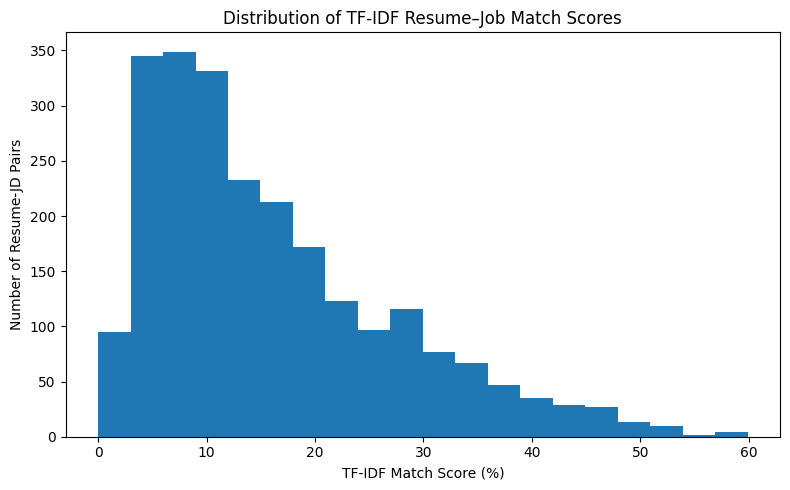

In [9]:
# TF-IDF score distribution
plt.figure(figsize=(8, 5))
plt.hist(df["tfidf_match_score"], bins=20)
plt.xlabel("TF-IDF Match Score (%)")
plt.ylabel("Number of Resume-JD Pairs")
plt.title("Distribution of TF-IDF Resume–Job Match Scores")
plt.tight_layout()
plt.show()


## 5. Semantic NLP — Sentence Transformers

The project uses the pretrained **`all-MiniLM-L6-v2`** Sentence Transformer.

Unlike TF-IDF, sentence embeddings represent text in a semantic vector space. This allows the system to recognize related meaning even when the exact words are different.

The model is used only for generating embeddings; no supervised training is performed in this project.


In [10]:
# Load Sentence Transformer
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Sentence Transformer loaded successfully!")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Sentence Transformer loaded successfully!


In [11]:
# Generate embeddings
resume_embeddings = model.encode(
    df["clean_resume"].tolist(),
    show_progress_bar=True
)

job_embeddings = model.encode(
    df["clean_job"].tolist(),
    show_progress_bar=True
)

print("Resume embedding shape:", resume_embeddings.shape)
print("Job embedding shape:", job_embeddings.shape)


Batches:   0%|          | 0/75 [00:00<?, ?it/s]

Batches:   0%|          | 0/75 [00:00<?, ?it/s]

Resume embedding shape: (2385, 384)
Job embedding shape: (2385, 384)


In [12]:
# Calculate semantic cosine similarity
semantic_scores = []

for i in range(len(df)):
    score = cosine_similarity(
        [resume_embeddings[i]],
        [job_embeddings[i]]
    )[0][0]
    semantic_scores.append(score * 100)

df["semantic_match_score"] = np.array(semantic_scores)

print("Semantic similarity calculation completed!")


Semantic similarity calculation completed!


In [13]:
# Compare similarity methods
comparison = df[
    [
        "category",
        "tfidf_match_score",
        "semantic_match_score",
        "ai_match_score"
    ]
].copy()

display(comparison.head(10))

print("Average TF-IDF Score:",
      round(df["tfidf_match_score"].mean(), 2))

print("Average Semantic Score:",
      round(df["semantic_match_score"].mean(), 2))

print("Average Dataset AI Reference Score:",
      round(df["ai_match_score"].mean(), 2))


,category,tfidf_match_score,semantic_match_score,ai_match_score
0,HR,17.730004,61.248028,49.40
1,HR,17.830773,57.842655,77.64
2,HR,27.616417,57.674744,100.00
3,HR,11.640698,53.436340,32.63
4,HR,49.073211,71.296692,86.03
5,HR,15.564662,48.099781,73.15
6,HR,27.418512,66.486740,71.36
7,HR,26.582719,69.472519,86.03
8,HR,27.385781,72.038528,95.81
9,HR,40.107941,57.222576,90.92


Average TF-IDF Score: 16.03
Average Semantic Score: 51.93
Average Dataset AI Reference Score: 44.04


In [14]:
# Correlation analysis
correlation = df[
    [
        "tfidf_match_score",
        "semantic_match_score",
        "ai_match_score"
    ]
].corr()

display(correlation)


,tfidf_match_score,semantic_match_score,ai_match_score
tfidf_match_score,1.000000,0.667318,0.673338
semantic_match_score,0.667318,1.000000,0.587500
ai_match_score,0.673338,0.587500,1.000000


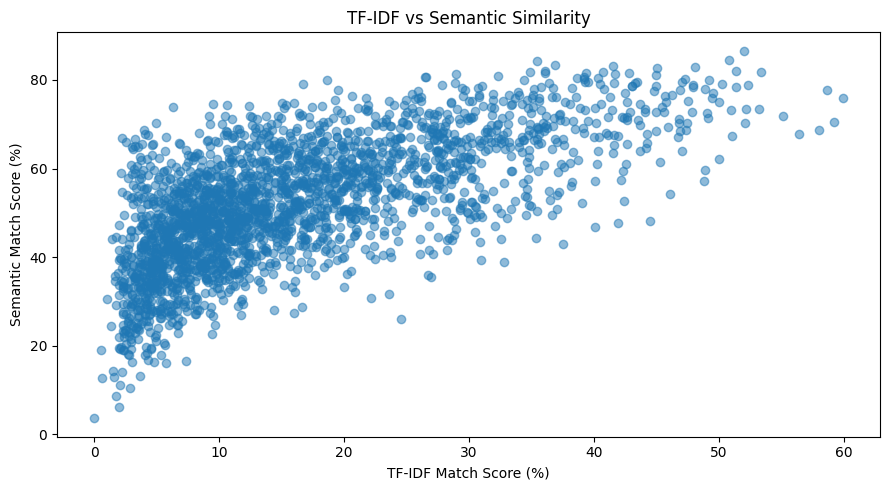

In [15]:
# TF-IDF vs Semantic Similarity
plt.figure(figsize=(9, 5))
plt.scatter(
    df["tfidf_match_score"],
    df["semantic_match_score"],
    alpha=0.5
)
plt.xlabel("TF-IDF Match Score (%)")
plt.ylabel("Semantic Match Score (%)")
plt.title("TF-IDF vs Semantic Similarity")
plt.tight_layout()
plt.show()


## 6. Skill Gap Analysis

The dataset provides:
- `job_required_skills`
- `resume_skill_list`

The lists are parsed and compared using set intersection and set difference.

- **Matching skills** = required skills also present in the resume skill list
- **Missing skills** = required skills absent from the resume skill list


In [16]:
def parse_skills(skill_text):
    try:
        skills = ast.literal_eval(skill_text)
        if isinstance(skills, (list, tuple, set)):
            return set(str(skill).lower().strip() for skill in skills)
    except Exception:
        pass
    return set()

df["required_skills"] = df["job_required_skills"].apply(parse_skills)
df["candidate_skills"] = df["resume_skill_list"].apply(parse_skills)

def find_skill_gaps(row):
    required = row["required_skills"]
    candidate = row["candidate_skills"]

    matching = required.intersection(candidate)
    missing = required.difference(candidate)

    return pd.Series({
        "matching_skills": sorted(matching),
        "missing_skills": sorted(missing)
    })

df[["matching_skills", "missing_skills"]] = df.apply(
    find_skill_gaps,
    axis=1
)

def skill_match_percentage(row):
    required = row["required_skills"]
    matching = row["matching_skills"]

    if len(required) == 0:
        return 0.0

    return (len(matching) / len(required)) * 100

df["skill_match_percentage"] = df.apply(
    skill_match_percentage,
    axis=1
)

print("Skill gap analysis completed!")


Skill gap analysis completed!


In [17]:
# Example skill-gap analysis
row = df.iloc[0]

print("JOB CATEGORY:")
print(row["category"])

print("\nREQUIRED SKILLS:")
print(row["required_skills"])

print("\nCANDIDATE SKILLS:")
print(row["candidate_skills"])

print("\nMATCHING SKILLS:")
print(row["matching_skills"])

print("\nMISSING SKILLS:")
print(row["missing_skills"])

print(f"\nSkill Match Percentage: {row['skill_match_percentage']:.2f}%")


JOB CATEGORY:
HR

REQUIRED SKILLS:
{'succession planning', 'business acumen', 'talent acquisition', 'problem solving', 'teamwork', 'confidentiality', 'project management', 'training and development', 'critical thinking', 'microsoft office suite', 'communication', 'performance management', 'influencing', 'compensation and benefits', 'employee relations', 'organizational development', 'hris systems', 'change management', 'hr analytics', 'employment law compliance', 'data analysis', 'human resources management', 'ethical judgment', 'interpersonal skills'}

CANDIDATE SKILLS:
{'website design', 'insurance', 'medical billing', 'financial management', 'leadership', 'multi-tasking', 'human resources', 'conflict resolution', 'problem solving', 'analytical skills', 'marketing', 'organizational skills', 'collaboration', 'creativity', 'training', 'labor relations', 'client relations', 'public relations', 'customer service', 'communication', 'customer focus', 'performance reviews', 'budgeting', 'de

## 7. Hybrid Resume–Job Matching

To combine the strengths of both approaches:

**Hybrid Score = 0.4 × TF-IDF Score + 0.6 × Semantic Score**

The semantic component receives a larger weight because it captures contextual similarity, while TF-IDF provides a transparent lexical baseline.

The weights are a **heuristic design choice**, not learned optimal weights.


In [18]:
# Hybrid score
df["hybrid_match_score"] = (
    0.4 * df["tfidf_match_score"] +
    0.6 * df["semantic_match_score"]
)

def classify_match(score):
    if score >= 70:
        return "Strong Match"
    elif score >= 45:
        return "Moderate Match"
    else:
        return "Low Match"

df["match_category"] = df["hybrid_match_score"].apply(classify_match)

print("Hybrid scoring completed!")


Hybrid scoring completed!


In [19]:
# Final results table
final_results = df[
    [
        "category",
        "tfidf_match_score",
        "semantic_match_score",
        "hybrid_match_score",
        "skill_match_percentage",
        "match_category"
    ]
].copy()

final_results.columns = [
    "Job Category",
    "TF-IDF Score (%)",
    "Semantic Score (%)",
    "Hybrid Score (%)",
    "Skill Match (%)",
    "Result"
]

display(final_results.head(10))


,Job Category,TF-IDF Score (%),Semantic Score (%),Hybrid Score (%),Skill Match (%),Result
0,HR,17.730004,61.248028,43.840819,12.500000,Low Match
1,HR,17.830773,57.842655,41.837902,16.666667,Low Match
2,HR,27.616417,57.674744,45.651414,20.833333,Moderate Match
3,HR,11.640698,53.436340,36.718085,8.333333,Low Match
4,HR,49.073211,71.296692,62.407300,29.166667,Moderate Match
5,HR,15.564662,48.099781,35.085734,16.666667,Low Match
6,HR,27.418512,66.486740,50.859449,29.166667,Moderate Match
7,HR,26.582719,69.472519,52.316601,8.333333,Moderate Match
8,HR,27.385781,72.038528,54.177430,25.000000,Moderate Match
9,HR,40.107941,57.222576,50.376722,33.333333,Moderate Match


## 8. Evaluation — Genuine vs Controlled Mismatched Pairs

The dataset does not provide independently verified human relevance labels, so we do not claim classification accuracy against a ground-truth relevance label.

Instead, we perform a **controlled pairwise evaluation**:

- **Positive pair:** the original resume and its associated job description.
- **Negative pair:** the same resume paired with a job description from a **different job category**.

The mismatched pairs are automatically constructed for experimental comparison. They should be interpreted as controlled negatives, not as human-verified judgments of relevance.

We calculate average similarity and ROC-AUC to compare how well TF-IDF and semantic similarity separate the genuine pairs from these deliberately mismatched pairs.



In [20]:
# Create controlled mismatched pairs from different job categories
# Fixed seed makes the experiment reproducible.
rng = np.random.default_rng(42)

categories = df["category"].astype(str).values
all_indices = np.arange(len(df))
negative_job_indices = np.empty(len(df), dtype=int)

for i, category in enumerate(categories):
    candidates = all_indices[categories != category]
    negative_job_indices[i] = rng.choice(candidates)

negative_tfidf_scores = []
negative_semantic_scores = []

for i, j in enumerate(negative_job_indices):
    tfidf_score = cosine_similarity(
        resume_vectors[i],
        job_vectors[j]
    )[0][0] * 100

    semantic_score = cosine_similarity(
        [resume_embeddings[i]],
        [job_embeddings[j]]
    )[0][0] * 100

    negative_tfidf_scores.append(tfidf_score)
    negative_semantic_scores.append(semantic_score)

evaluation_df = pd.DataFrame({
    "label": [1] * len(df) + [0] * len(df),
    "pair_type": ["Genuine"] * len(df) + ["Different-category mismatch"] * len(df),
    "tfidf_score": (
        df["tfidf_match_score"].tolist() + negative_tfidf_scores
    ),
    "semantic_score": (
        df["semantic_match_score"].tolist() + negative_semantic_scores
    )
})

print("Evaluation pairs:", len(evaluation_df))
print("Positive pairs:", len(df))
print("Controlled negative pairs:", len(df))
display(evaluation_df.head())


Evaluation pairs: 4770
Positive pairs: 2385
Controlled negative pairs: 2385


,label,pair_type,tfidf_score,semantic_score
0,1,Genuine,17.730004,61.248028
1,1,Genuine,17.830773,57.842655
2,1,Genuine,27.616417,57.674744
3,1,Genuine,11.640698,53.436340
4,1,Genuine,49.073211,71.296692


In [21]:
# Positive vs negative score comparison
positive = evaluation_df[evaluation_df["label"] == 1]
negative = evaluation_df[evaluation_df["label"] == 0]

print("Average TF-IDF similarity")
print("  Genuine pairs:   ", round(positive["tfidf_score"].mean(), 2))
print("  Mismatched pairs:", round(negative["tfidf_score"].mean(), 2))

print("\nAverage Semantic similarity")
print("  Genuine pairs:   ", round(positive["semantic_score"].mean(), 2))
print("  Mismatched pairs:", round(negative["semantic_score"].mean(), 2))


Average TF-IDF similarity
  Genuine pairs:    16.03
  Mismatched pairs: 5.24

Average Semantic similarity
  Genuine pairs:    51.93
  Mismatched pairs: 34.45


In [22]:
# ROC-AUC evaluation
tfidf_auc = roc_auc_score(
    evaluation_df["label"],
    evaluation_df["tfidf_score"]
)

semantic_auc = roc_auc_score(
    evaluation_df["label"],
    evaluation_df["semantic_score"]
)

print(f"TF-IDF ROC-AUC: {tfidf_auc:.3f}")
print(f"Semantic ROC-AUC: {semantic_auc:.3f}")


TF-IDF ROC-AUC: 0.853
Semantic ROC-AUC: 0.843


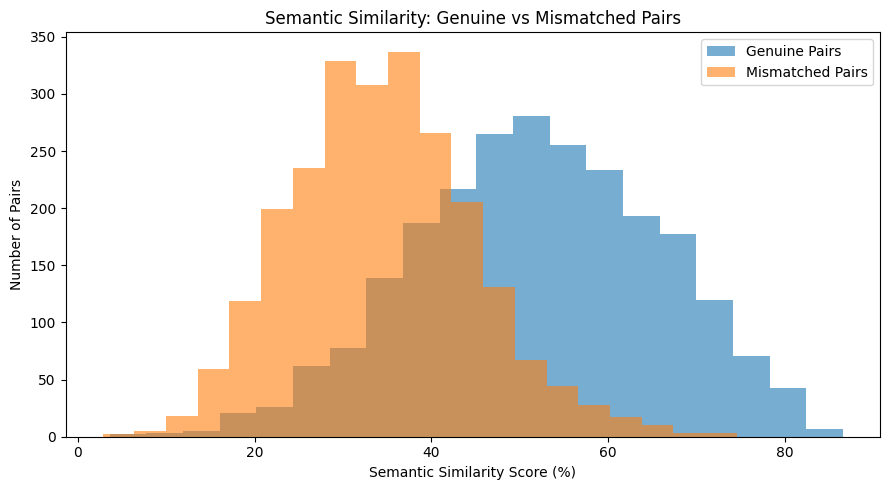

In [23]:
# Visualize genuine vs mismatched scores
plt.figure(figsize=(9, 5))

plt.hist(
    positive["semantic_score"],
    bins=20,
    alpha=0.6,
    label="Genuine Pairs"
)

plt.hist(
    negative["semantic_score"],
    bins=20,
    alpha=0.6,
    label="Mismatched Pairs"
)

plt.xlabel("Semantic Similarity Score (%)")
plt.ylabel("Number of Pairs")
plt.title("Semantic Similarity: Genuine vs Mismatched Pairs")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Multi-Pair Testing

The system is tested on several different resume–job pairs rather than relying on a single example.


In [24]:
test_indices = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]

test_results = []

for i in test_indices:
    test_results.append({
        "Index": i,
        "Category": df.loc[i, "category"],
        "TF-IDF (%)": round(df.loc[i, "tfidf_match_score"], 2),
        "Semantic (%)": round(df.loc[i, "semantic_match_score"], 2),
        "Hybrid (%)": round(df.loc[i, "hybrid_match_score"], 2),
        "Skill Match (%)": round(df.loc[i, "skill_match_percentage"], 2),
        "Result": df.loc[i, "match_category"]
    })

test_df = pd.DataFrame(test_results)
display(test_df)


,Index,Category,TF-IDF (%),Semantic (%),Hybrid (%),Skill Match (%),Result
0,0,HR,17.73,61.250000,43.84,12.50,Low Match
1,10,HR,17.21,71.690002,49.90,16.67,Moderate Match
2,20,HR,10.88,56.570000,38.30,4.17,Low Match
3,30,HR,26.15,66.769997,50.52,16.67,Moderate Match
4,40,HR,17.89,63.700001,45.38,12.50,Moderate Match
5,50,HR,13.23,50.060001,35.32,12.50,Low Match
6,60,HR,30.26,58.049999,46.94,29.17,Moderate Match
7,70,HR,27.63,60.279999,47.22,20.83,Moderate Match
8,80,HR,23.61,72.199997,52.76,29.17,Moderate Match
9,90,HR,35.50,65.620003,53.57,16.67,Moderate Match


match_category
Low Match         1777
Moderate Match     604
Strong Match         4
Name: count, dtype: int64


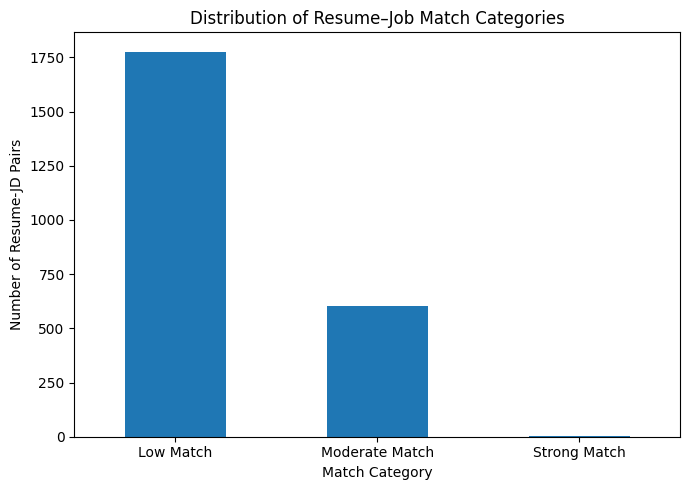

In [25]:
# Match-category distribution
match_distribution = df["match_category"].value_counts()

print(match_distribution)

plt.figure(figsize=(7, 5))
match_distribution.plot(kind="bar")
plt.xlabel("Match Category")
plt.ylabel("Number of Resume-JD Pairs")
plt.title("Distribution of Resume–Job Match Categories")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [26]:
# Skill-match statistics
print("Skill Match Statistics")
print("----------------------")
print(f"Average Skill Match: {df['skill_match_percentage'].mean():.2f}%")
print(f"Highest Skill Match: {df['skill_match_percentage'].max():.2f}%")
print(f"Lowest Skill Match: {df['skill_match_percentage'].min():.2f}%")


Skill Match Statistics
----------------------
Average Skill Match: 11.55%
Highest Skill Match: 41.67%
Lowest Skill Match: 0.00%


## 10. Category-Level Analysis

The following table and graph show the average similarity scores across job categories.


In [27]:
category_results = df.groupby("category")[
    [
        "tfidf_match_score",
        "semantic_match_score",
        "hybrid_match_score",
        "skill_match_percentage"
    ]
].mean().sort_values(
    "hybrid_match_score",
    ascending=False
)

display(category_results)


,tfidf_match_score,semantic_match_score,hybrid_match_score,skill_match_percentage
category,,,,
CHEF,26.805903,67.947739,51.491005,17.070218
HR,25.531317,63.972630,48.596106,20.416667
CONSTRUCTION,26.242028,60.194317,46.613403,9.821429
FINANCE,21.806396,59.801056,44.603194,15.279163
BUSINESS-DEVELOPMENT,18.763695,61.165108,44.204545,18.277778
PUBLIC-RELATIONS,20.968031,55.725906,41.822759,18.393393
ACCOUNTANT,11.773544,59.890938,40.643981,7.229873
FITNESS,21.170660,53.264400,40.426905,11.111111
DIGITAL-MEDIA,19.065638,52.655716,39.219687,14.192708


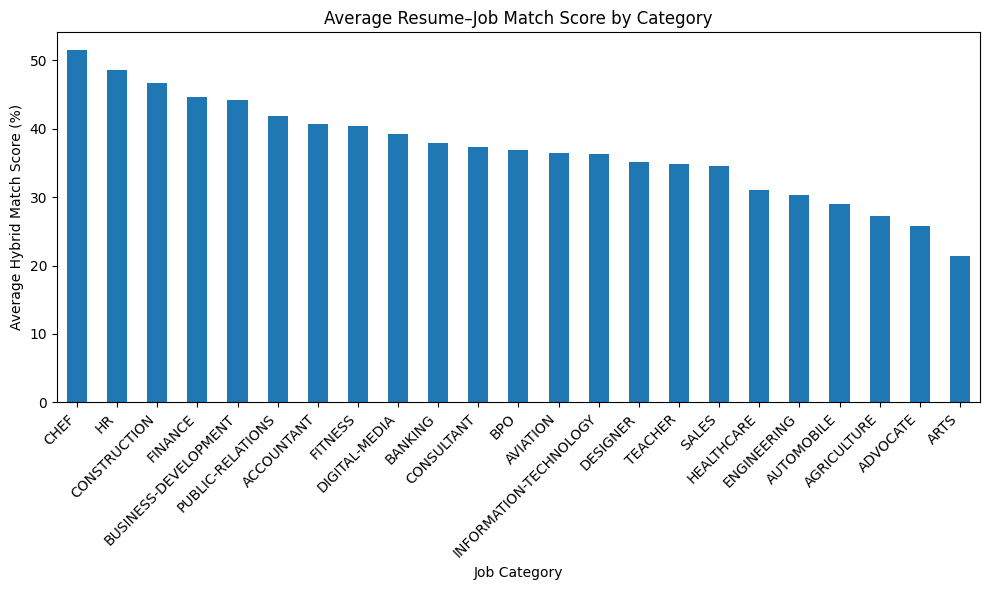

In [28]:
plt.figure(figsize=(10, 6))
category_results["hybrid_match_score"].plot(kind="bar")
plt.xlabel("Job Category")
plt.ylabel("Average Hybrid Match Score (%)")
plt.title("Average Resume–Job Match Score by Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 11. Interesting Case Study

This finds a pair where semantic similarity is substantially higher than TF-IDF similarity.

Such cases illustrate how semantic embeddings can capture related meaning even when the exact vocabulary differs.


In [29]:
df["semantic_tfidf_difference"] = (
    df["semantic_match_score"] -
    df["tfidf_match_score"]
)

interesting_index = df["semantic_tfidf_difference"].idxmax()
interesting_case = df.loc[interesting_index]

print("Category:", interesting_case["category"])
print("TF-IDF Score:", round(interesting_case["tfidf_match_score"], 2))
print("Semantic Score:", round(interesting_case["semantic_match_score"], 2))
print(
    "Difference:",
    round(interesting_case["semantic_tfidf_difference"], 2)
)


Category: AVIATION
TF-IDF Score: 6.27
Semantic Score: 73.99
Difference: 67.72


## 12. Reference-Score Comparison

The dataset contains an `ai_match_score`. Because this score is already supplied by the dataset and is not independently verified, it is treated only as a **reference/auxiliary comparison**, not as ground truth.

This section helps investigate whether the project's hybrid score behaves similarly to the dataset's existing AI-based score.


In [30]:
reference_corr = df[
    ["hybrid_match_score", "ai_match_score"]
].corr().iloc[0, 1]

print(
    f"Correlation between Hybrid Score and Dataset AI Reference Score: "
    f"{reference_corr:.3f}"
)


Correlation between Hybrid Score and Dataset AI Reference Score: 0.671


## 13. Final SmartResume Application Function

The function below turns the project into a reusable mini application.

For a new resume and job description, it:
1. Cleans the text.
2. Computes TF-IDF similarity.
3. Computes semantic similarity.
4. Calculates the hybrid score.
5. Extracts skills using a dataset-derived vocabulary supplemented with common technical skills.
6. Reports matching and missing skills.
7. Produces a simple recommendation.

**Note:** Skill extraction is rule-based. It depends on the selected vocabulary and may miss synonyms or skills that are not represented in that vocabulary.


In [34]:
# Corrected SmartResume application function
# This version uses a clean technical-skill vocabulary to avoid
# false matches such as "analyst", "analysis", "learning", and "A+".

application_skills = {
    "python", "sql", "pandas", "numpy", "scikit-learn",
    "machine learning", "deep learning", "natural language processing",
    "nlp", "data analysis", "data preprocessing", "data visualization",
    "statistical analysis", "statistics", "excel", "power bi",
    "tensorflow", "pytorch", "java", "c++", "javascript",
    "html", "css", "flask", "django", "node.js", "react",
    "mysql", "mongodb", "git", "github", "tableau",
    "communication", "problem solving", "teamwork"
}

skill_vocabulary = sorted(application_skills)


def extract_skills_from_text(text, vocabulary):
    """Extract technical skills using complete phrase matching."""
    cleaned = clean_text(text)
    found = set()

    for skill in vocabulary:
        skill_clean = clean_text(skill)

        if not skill_clean:
            continue

        pattern = r"(?<!\w)" + re.escape(skill_clean) + r"(?!\w)"

        if re.search(pattern, cleaned):
            found.add(skill)

    return found


def smart_resume_analysis(resume_text, job_text):
    """Analyze a resume against a job description."""

    clean_resume = clean_text(resume_text)
    clean_job = clean_text(job_text)

    # TF-IDF using the already-fitted dataset vectorizer
    input_vectors = tfidf_vectorizer.transform(
        [clean_resume, clean_job]
    )

    tfidf_score = cosine_similarity(
        input_vectors[0],
        input_vectors[1]
    )[0][0] * 100

    # Semantic similarity
    resume_embedding = model.encode([clean_resume])
    job_embedding = model.encode([clean_job])

    semantic_score = cosine_similarity(
        resume_embedding,
        job_embedding
    )[0][0] * 100

    # Hybrid score
    hybrid_score = (
        0.4 * tfidf_score +
        0.6 * semantic_score
    )

    # Skill-gap analysis
    required_skills = extract_skills_from_text(
        job_text,
        skill_vocabulary
    )

    candidate_skills = extract_skills_from_text(
        resume_text,
        skill_vocabulary
    )

    matching_skills = required_skills.intersection(
        candidate_skills
    )

    missing_skills = required_skills.difference(
        candidate_skills
    )

    skill_match = (
        (len(matching_skills) / len(required_skills)) * 100
        if required_skills else 0.0
    )

    result = classify_match(hybrid_score)

    if missing_skills:
        recommendations = [
            f"Consider improving or gaining experience in: {skill}."
            for skill in sorted(missing_skills)[:5]
        ]
    else:
        recommendations = [
            "No major skill gaps were detected from the selected skill vocabulary."
        ]

    return {
        "TF-IDF Score (%)": round(tfidf_score, 2),
        "Semantic Score (%)": round(semantic_score, 2),
        "Hybrid Match Score (%)": round(hybrid_score, 2),
        "Overall Result": result,
        "Matching Skills": sorted(matching_skills),
        "Missing Skills": sorted(missing_skills),
        "Skill Match (%)": round(skill_match, 2),
        "Recommendations": recommendations
    }


print("SmartResume analyzer is ready!")
print("Number of skills in application vocabulary:", len(skill_vocabulary))

SmartResume analyzer is ready!
Number of skills in application vocabulary: 35


## 14. Final Demo

The demonstration below applies SmartResume to a new resume and job description.

The output shows lexical similarity, semantic similarity, the hybrid match score, skill overlap, missing skills, and recommendations.


In [35]:
# Final demonstration with a realistic resume and job description

sample_resume = """
BCA student with hands-on experience in Python, SQL, Pandas,
NumPy, scikit-learn, machine learning and NLP.
Completed academic projects involving data preprocessing,
data analysis and data visualization.
"""

sample_job = """
We are looking for a junior data analyst with skills in Python,
SQL, Pandas, machine learning and NLP.
The candidate should have knowledge of data preprocessing,
data visualization and statistical analysis.
"""

demo_result = smart_resume_analysis(sample_resume, sample_job)

print("SMARTRESUME ANALYSIS")
print("====================")
print(f"TF-IDF Score: {demo_result['TF-IDF Score (%)']}%")
print(f"Semantic Score: {demo_result['Semantic Score (%)']}%")
print(f"Hybrid Match Score: {demo_result['Hybrid Match Score (%)']}%")
print(f"Overall Result: {demo_result['Overall Result']}")
print(f"Skill Match: {demo_result['Skill Match (%)']}%")

print("\nMatching Skills:")
for skill in demo_result["Matching Skills"]:
    print("✓", skill)

print("\nMissing Skills:")
for skill in demo_result["Missing Skills"]:
    print("✗", skill)

print("\nRecommendations:")
for recommendation in demo_result["Recommendations"]:
    print("-", recommendation)


SMARTRESUME ANALYSIS
TF-IDF Score: 62.52%
Semantic Score: 78.22000122070312%
Hybrid Match Score: 71.94%
Overall Result: Strong Match
Skill Match: 87.5%

Matching Skills:
✓ data preprocessing
✓ data visualization
✓ machine learning
✓ nlp
✓ pandas
✓ python
✓ sql

Missing Skills:
✗ statistical analysis

Recommendations:
- Consider improving or gaining experience in: statistical analysis.


## 15. Results Summary

The main experimental observations should be reported using the values produced by the notebook.

### Metrics to report
- Average TF-IDF similarity
- Average semantic similarity
- TF-IDF vs semantic correlation
- Genuine vs mismatched average scores
- TF-IDF ROC-AUC
- Semantic ROC-AUC
- Hybrid/reference-score correlation
- Average skill-match percentage
- Distribution of Strong/Moderate/Low matches

### Interpretation
TF-IDF provides an interpretable lexical baseline, while Sentence Transformer embeddings provide a semantic representation. The hybrid score combines both signals. Skill-gap analysis adds an explainable layer by showing which required skills are present or absent.

Do **not** describe the dataset's `ai_match_score` as ground truth.


## 16. Limitations

1. The dataset does not provide independently verified human relevance labels.
2. The hybrid weights (40% TF-IDF and 60% semantic) are heuristic rather than learned.
3. The Strong/Moderate/Low thresholds are heuristic.
4. Rule-based skill extraction depends on the dataset-derived vocabulary.
5. Synonyms and equivalent skill phrases may not always be detected.
6. Sentence Transformer inference can be slower than TF-IDF.
7. The system does not assess candidate experience quality, seniority, achievements, or context beyond the supplied text.
8. The reference `ai_match_score` comes from the dataset and should not be treated as ground truth.


## 17. Future Scope

1. Train or calibrate the hybrid scoring weights using human-labeled resume–job relevance data.
2. Add synonym and skill-ontology matching.
3. Extract skills using a trained NER model instead of only a rule-based vocabulary.
4. Support PDF/DOCX resume upload and automatic text extraction.
5. Add explainable highlighting of matched resume phrases.
6. Experiment with stronger domain-adapted transformer models.
7. Add a recruiter dashboard for ranking multiple candidates.
8. Add multilingual resume and job-description support.
9. Evaluate the system using a larger human-annotated benchmark.


## 18. Conclusion

SmartResume demonstrates an NLP-based approach to resume–job matching by comparing a traditional TF-IDF baseline with semantic sentence embeddings. The hybrid approach combines lexical overlap and contextual similarity, while skill-gap analysis provides an interpretable explanation of missing requirements.

The project also demonstrates that evaluating an NLP matching system requires care when a dataset lacks verified ground-truth relevance labels. Therefore, controlled genuine-versus-mismatched evaluation and auxiliary reference-score comparisons are used instead of unsupported accuracy claims.

Overall, the project combines classical NLP, modern semantic representation, similarity measurement, and explainable skill analysis in a small working application.
